# 3 · Measurement models

**Recap** ([theory](https://github.com/Rudip1/learn-state-estimation/blob/main/1_theory/03_measurement_models.md)).
A measurement model $z = h(x) + v$, $v\sim\mathcal N(0,R)$, predicts a reading from a state; its likelihood
$p(z\mid x) = \mathcal N(z; h(x), R)$ scores a hypothesis (angles in the residual are wrapped). Range–bearing:
$\rho = \lVert m - p\rVert$, $\phi = \operatorname{atan2}(\Delta_y,\Delta_x) - \theta$, with Jacobians $H_x$, $H_m$.
The inverse model $g(x,z)$ places a landmark and gives its covariance $G_xPG_x^T + G_zRG_z^T$. Cartesian
features are $R(\theta)^T(m - p)$; polar noise becomes range-dependent Cartesian noise. A position fix observes
$(x, y)$, a compass $\theta$. The rank of the Fisher information $H^TR^{-1}H$ tells which directions are observed.

In [1]:
# Installs the module when it is not available yet (e.g. on Colab). Building the C++ takes a few minutes.
try:
    import state_estimation
except ImportError:
    %pip install -q git+https://github.com/Rudip1/learn-state-estimation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import state_estimation as se
from state_estimation import plotting

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (6, 4.5)})

## A simulated landmark sensor

A sensor with 6 m range and a 120° field of view looks at a map of landmarks. Each reading comes with the index
of the landmark that produced it (known correspondences).

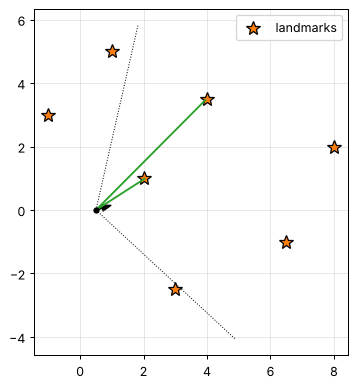

0 range 1.813  bearing +0.271   expected [1.803 0.288]
1 range 4.882  bearing +0.488   expected [4.95  0.485]


In [3]:
landmarks = np.array([[2.0, 1.0], [4.0, 3.5], [6.5, -1.0], [-1.0, 3.0], [3.0, -2.5], [8.0, 2.0], [1.0, 5.0]])
sensor = se.RangeBearingSensor(max_range=6.0, fov=np.deg2rad(120), sigma_range=0.1, sigma_bearing=np.deg2rad(2))
x_true = np.array([0.5, 0.0, 0.3])
obs = sensor.observe(x_true, landmarks, se.Rng(0))

ax = plotting.new_axes()
ax.plot(landmarks[:, 0], landmarks[:, 1], "*", color=plotting.COLORS["landmark"], ms=12, mec="k", label="landmarks")
for o in obs:
    p = se.range_bearing_inverse(x_true, o.z)
    ax.plot([x_true[0], p[0]], [x_true[1], p[1]], "-", color=plotting.COLORS["measurement"])
for a in (-1, 1):
    ang = x_true[2] + a * sensor.fov / 2
    ax.plot([x_true[0], x_true[0] + 6 * np.cos(ang)], [x_true[1], x_true[1] + 6 * np.sin(ang)], "k:", lw=0.8)
plotting.plot_pose(ax, x_true, 0.5)
ax.legend(); plt.show()
for o in obs:
    print(o.landmark, "range %.3f  bearing %+.3f   expected" % tuple(o.z), se.range_bearing(x_true, landmarks[o.landmark]).round(3))

### ✏️ Exercise 1 — the range–bearing model and its Jacobian

Implement eq. (3.4) and the pose Jacobian of eq. (3.5). Wrap the bearing.

In [4]:
def range_bearing_np(x, m):
    ### BEGIN SOLUTION
    dx, dy = m[0] - x[0], m[1] - x[1]
    return np.array([np.hypot(dx, dy), se.wrap_angle(np.arctan2(dy, dx) - x[2])])
    ### END SOLUTION

def H_pose_np(x, m):
    ### BEGIN SOLUTION
    dx, dy = m[0] - x[0], m[1] - x[1]
    q = dx * dx + dy * dy
    r = np.sqrt(q)
    return np.array([[-dx / r, -dy / r, 0.0], [dy / q, -dx / q, -1.0]])
    ### END SOLUTION

In [5]:
rng = np.random.default_rng(1)
for _ in range(50):
    x, m = rng.uniform(-5, 5, 3), rng.uniform(-5, 5, 2)
    assert np.allclose(range_bearing_np(x, m), se.range_bearing(x, m))
    assert np.allclose(H_pose_np(x, m), se.numerical_jacobian(lambda p: se.range_bearing(p, m), x), atol=1e-6)
print("worked example:", range_bearing_np([1, 1, np.pi / 2], [1, 3]), range_bearing_np([1, 1, np.pi / 2], [3, 1]))

worked example: [2. 0.] [ 2.         -1.57079633]


### ✏️ Exercise 2 — where is the landmark, and how sure are we?

The robot is at $\hat x = (0, 0, 0)$ with covariance $P = \operatorname{diag}(0.05^2, 0.05^2, 0.05^2)$ and reads
$z = (5\text{ m}, 0.4\text{ rad})$ with the sensor noise above. Compute the landmark covariance with (3.8) and
compare it with a Monte Carlo estimate (sample pose and reading, apply `se.range_bearing_inverse`).

In [6]:
x_hat, P = np.zeros(3), np.diag([0.05**2, 0.05**2, 0.05**2])
z, R = np.array([5.0, 0.4]), sensor.R()

def landmark_covariance(x_hat, P, z, R):
    ### BEGIN SOLUTION
    Gx = se.range_bearing_inverse_jacobian_pose(x_hat, z)
    Gz = se.range_bearing_inverse_jacobian_measurement(x_hat, z)
    return Gx @ P @ Gx.T + Gz @ R @ Gz.T
    ### END SOLUTION

linearised
 [[ 0.02508 -0.02976]
 [-0.02976  0.08288]] 
Monte Carlo
 [[ 0.02536 -0.02996]
 [-0.02996  0.0828 ]]


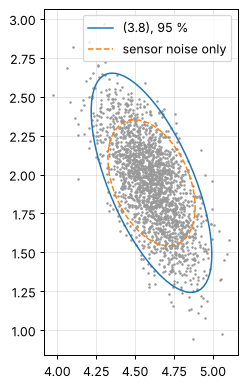

In [7]:
Pm = landmark_covariance(x_hat, P, z, R)
r = se.Rng(2)
X = se.sample_gaussian(x_hat, P, 20000, r)
Z = se.sample_gaussian(z, R, 20000, r)
M = np.array([se.range_bearing_inverse(xi, zi) for xi, zi in zip(X, Z)])
Pm_mc = np.cov(M.T)
print("linearised\n", Pm.round(5), "\nMonte Carlo\n", Pm_mc.round(5))
assert np.allclose(Pm, Pm_mc, rtol=0.1, atol=1e-4)

ax = plotting.new_axes()
ax.plot(M[::10, 0], M[::10, 1], ".", ms=2, color="0.6")
plotting.plot_ellipse(ax, se.range_bearing_inverse(x_hat, z), Pm, 0.95, label="(3.8), 95 %")
Gz = se.range_bearing_inverse_jacobian_measurement(x_hat, z)
plotting.plot_ellipse(ax, se.range_bearing_inverse(x_hat, z), Gz @ R @ Gz.T, 0.95, ls="--",
                      label="sensor noise only")
ax.legend(); plt.show()

## Polar noise in Cartesian coordinates

Converting readings to Cartesian coordinates is convenient, but their covariance (3.11) grows across the line of
sight with range.

ρ =  1 m: σ_max = 0.100 m
ρ =  2 m: σ_max = 0.100 m
ρ =  4 m: σ_max = 0.140 m
ρ =  6 m: σ_max = 0.209 m
ρ =  8 m: σ_max = 0.279 m
ρ = 10 m: σ_max = 0.349 m


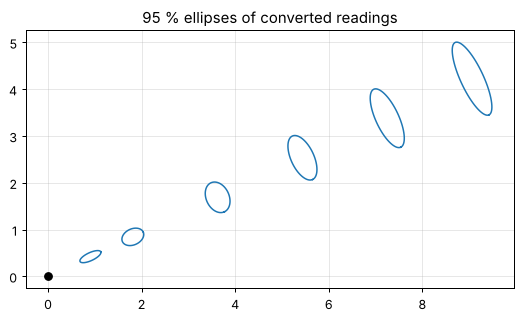

In [8]:
ax = plotting.new_axes(figsize=(7, 4))
for rho in (1, 2, 4, 6, 8, 10):
    zz = np.array([rho, np.deg2rad(25)])
    plotting.plot_ellipse(ax, se.polar_to_cartesian(zz), se.polar_to_cartesian_covariance(zz, sensor.R()), 0.95,
                          color="C0")
    C = se.polar_to_cartesian_covariance(zz, sensor.R())
    print(f"ρ = {rho:2d} m: σ_max = {np.sqrt(np.linalg.eigvalsh(C).max()):.3f} m")
ax.plot(0, 0, "ko"); ax.set_title("95 % ellipses of converted readings"); plt.show()

## Observability

### ✏️ Exercise 3 — what one landmark cannot see

Stack the range–bearing pose Jacobian of **one** landmark, build $\mathcal I = H^TR^{-1}H$ with
`se.fisher_information`, and return its rank and the unit null-space vector (eigenvector of the smallest
eigenvalue). Interpret the vector: it should move the robot sideways around the landmark while turning it so
that range and bearing stay the same.

In [9]:
def rank_and_null(H, R):
    ### BEGIN SOLUTION
    I = se.fisher_information(H, R)
    w, V = np.linalg.eigh(I)
    rank = int(np.sum(w > 1e-9 * w.max()))
    return rank, V[:, 0]
    ### END SOLUTION

In [10]:
x0 = np.array([0.0, 0.0, 0.0]); m = np.array([4.0, 0.0])
rank, n = rank_and_null(se.range_bearing_jacobian_pose(x0, m), sensor.R())
print("rank", rank, " null direction (dx, dy, dθ) =", n.round(3))
assert rank == 2
# moving along n leaves the reading unchanged to first order
assert np.allclose(se.range_bearing_jacobian_pose(x0, m) @ n, 0, atol=1e-9)
H2 = np.vstack([se.range_bearing_jacobian_pose(x0, m), se.range_bearing_jacobian_pose(x0, [0.0, 3.0])])
assert rank_and_null(H2, np.kron(np.eye(2), sensor.R()))[0] == 3
print("two landmarks: full rank")

rank 2  null direction (dx, dy, dθ) = [ 0.    -0.97   0.243]
two landmarks: full rank


The null direction is $\pm(0, 4, -1)/\sqrt{17}$: moving sideways by $\delta$ while turning by $-\delta/4$ keeps
the landmark, 4 m ahead, at the same range and bearing — to first order, a rotation of the robot about the
landmark.

## 🔨 Break it — forgetting to wrap the bearing residual

A landmark is almost directly behind the robot (bearing ≈ ±π). Evaluate the log-likelihood as a function of the
hypothesised heading with and without wrapping the residual. Without wrapping, a tiny heading change flips the
bearing from $+\pi$ to $-\pi$ and the likelihood collapses: the filter would reject a perfectly good reading.

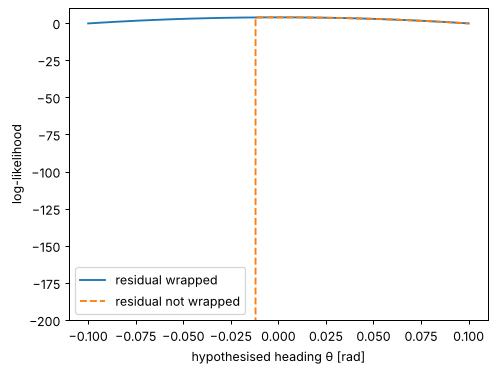

In [11]:
m_behind = np.array([-4.0, 0.05])
z_b = se.range_bearing(np.zeros(3), m_behind)
R = sensor.R()
headings = np.linspace(-0.1, 0.1, 401)
wrapped = [se.measurement_log_likelihood(z_b, se.range_bearing([0, 0, h], m_behind), R, [1]) for h in headings]
raw = [se.measurement_log_likelihood(z_b, se.range_bearing([0, 0, h], m_behind), R, []) for h in headings]
plt.plot(headings, wrapped, label="residual wrapped")
plt.plot(headings, raw, "--", label="residual not wrapped")
plt.xlabel("hypothesised heading θ [rad]"); plt.ylabel("log-likelihood"); plt.ylim(-200, 10); plt.legend(); plt.show()

## 🔨 Break it — a constant Cartesian covariance

Convert readings of a landmark 9 m away to Cartesian coordinates and gate them with a covariance that is
isotropic and equal to the range variance (what you would guess from "the sensor is good to 10 cm"). The gate
should reject 5 % of genuine readings; it rejects far more, because the lateral error is $\rho\sigma_\phi$.

In [12]:
z9 = np.array([9.0, 0.3])
P_iso = np.eye(2) * sensor.sigma_range**2
P_ok = se.polar_to_cartesian_covariance(z9, sensor.R())
pts = np.array([se.polar_to_cartesian(s) for s in se.sample_gaussian(z9, sensor.R(), 5000, se.Rng(4))])
gate = se.chi2_quantile(0.95, 2)
for name, C in (("isotropic σ = σ_ρ", P_iso), ("J R Jᵀ (3.11)", P_ok)):
    rej = np.mean([se.mahalanobis_squared(p, se.polar_to_cartesian(z9), C) > gate for p in pts])
    print(f"{name:18s}: rejects {100 * rej:5.1f} % of genuine readings")

isotropic σ = σ_ρ : rejects  48.8 % of genuine readings
J R Jᵀ (3.11)     : rejects   5.0 % of genuine readings


## What to remember

- A measurement model gives a prediction $h(x)$, Jacobians and a likelihood; wrap angular residuals.
- The inverse model places a landmark; its covariance includes the robot's uncertainty and correlates the two.
- Polar noise is not isotropic in Cartesian coordinates: lateral uncertainty is $\rho\,\sigma_\phi$.
- The rank of $H^TR^{-1}H$ says what a set of readings can observe; one landmark is not enough for a pose,
  but motion can complete the picture over time.